In [41]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [42]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [43]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [44]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [45]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.

        return state == self.goal
            


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

        legal_actions=[]
        for key, value in MOVES.items():
            dr, dc = value
            row, col = state
            neighbour_cell = (row + dr, col + dc)

            if self.in_bounds (neighbour_cell) and self.is_free(neighbour_cell):
                legal_actions.append(key)

        return legal_actions
    

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
    

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
    

In [46]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [47]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [48]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

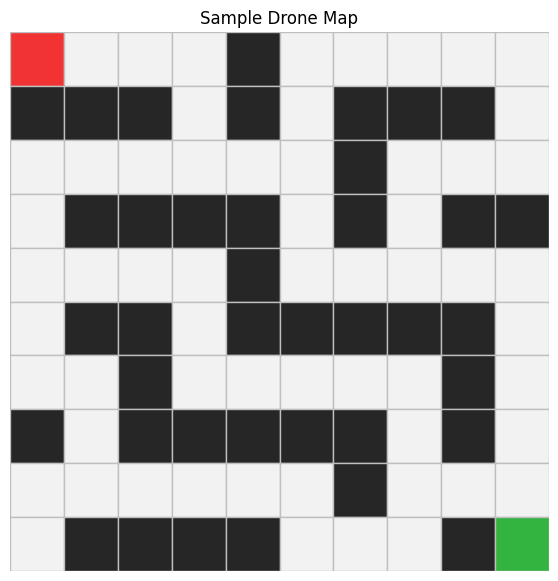

In [49]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [50]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state = s_prime, parent = node, action = action, path_cost = cost)
        
        # raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [51]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()

        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(algorithm=algorithm, status='success', solution=node,
                        nodes_expanded=0, max_frontier_size=1, reached_count=1, limit=None)
        
        frontier = deque([node])
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier_size = len(frontier)

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(algorithm=algorithm, status='success', solution=child,
                                nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size,
                                reached_count=len(reached), limit=None)
                
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)


                if len(frontier) > max_frontier_size:
                    max_frontier_size = len(frontier)
                    
        return SearchResult(algorithm=algorithm, status='failure', solution=None,
                    nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size,
                    reached_count=len(reached), limit=None)

        # raise NotImplementedError("Complete BreadthFirstSearch.search")

In [52]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.

        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(algorithm=algorithm, status='success', solution=node,
                        nodes_expanded=0, max_frontier_size=1, reached_count=1, limit=None)
        
        frontier = []
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier_size = len(frontier)

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            children = list(self.expand(problem, node))
            children.reverse()

            for child in children:
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(algorithm=algorithm, status='success', solution=child,
                                nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size,
                                reached_count=len(reached), limit=None)

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

                if len(frontier) > max_frontier_size:
                    max_frontier_size = len(frontier)

        return SearchResult(algorithm=algorithm, status='failure', solution=None,
                    nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size,
                    reached_count=len(reached), limit=None)
        
        # raise NotImplementedError("Complete DepthFirstSearch.search")

In [53]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        if problem.is_goal(node.state):
            return node, 'success'
        
        elif  node.depth >= limit:
            return None, 'cutoff'
        
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occurred = False

            children = list(self.expand(problem, node))

            for child in children:
                current_path = False
                ancestor= node
                while ancestor is not None:
                    if ancestor.state == child.state:
                        current_path = True
                        break
                    ancestor = ancestor.parent
                if current_path:
                    continue
                
                if current_stack_size +1 > metrics["max_stack_size"]:
                    metrics["max_stack_size"] = current_stack_size + 1

                result_node, result_status = self._recursive_dls(problem= problem, node= child, limit= limit, metrics= metrics, 
                                                                 current_stack_size= current_stack_size+1)
                if result_status == 'success':
                    return result_node, 'success'
                
                if result_status == 'cutoff':
                    cutoff_occurred = True 
            
            if cutoff_occurred:
                return None, 'cutoff'
            else:
                return None, 'failure'
            


        # raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [54]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

        iteration_log = []
        total_nodes = 0
        max_stack_size = 0

        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            iteration_log.append(result)
            total_nodes += result.nodes_expanded
            if result.max_frontier_size > max_stack_size:
                max_stack_size = result.max_frontier_size

            if result.status == 'success':
                return SearchResult(algorithm=algorithm, status='success', solution=result.solution,nodes_expanded=total_nodes,
                                     max_frontier_size=max_stack_size, reached_count=0, limit=limit)
            
            if result.status == 'failure':
                return SearchResult(algorithm=algorithm, status='failure', solution=None, nodes_expanded=total_nodes, 
                                    max_frontier_size=max_stack_size, reached_count=0, limit=limit)
            
        return SearchResult(algorithm=algorithm, status='cutoff', solution=None, nodes_expanded=total_nodes, 
                            max_frontier_size=max_stack_size, reached_count=0, limit=max_depth)

        
        # raise NotImplementedError("Complete IterativeDeepeningSearch.search")

In [55]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,failure,NaN,NaN,NaN,0,0,1
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


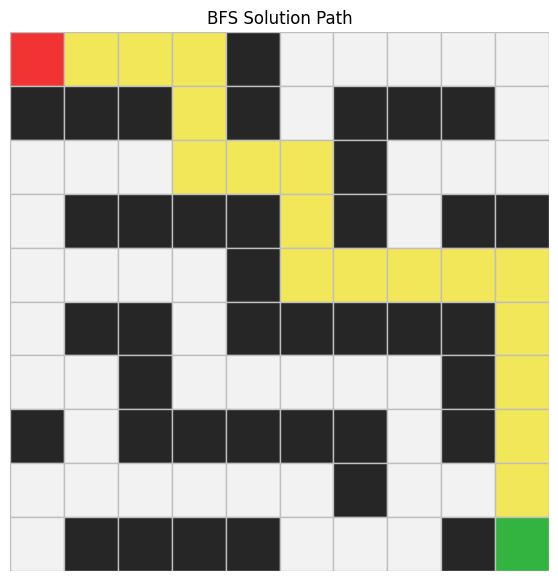

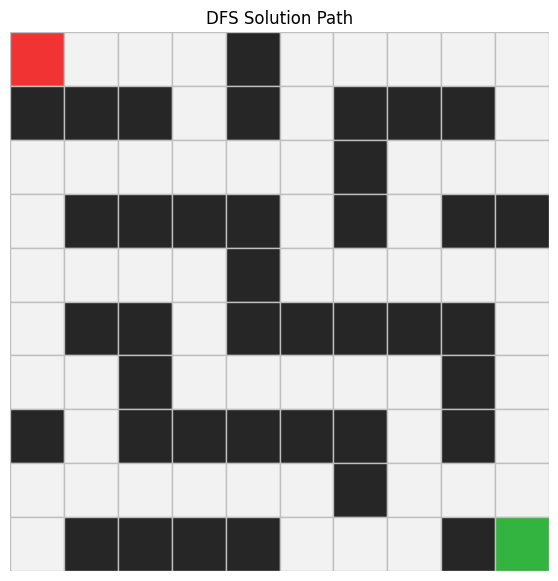

In [56]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [57]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    '0000000010',
    '0010001000',
    '0000101000',
    '1110011000',
    '0010001111',
    '0100111000',
    '0100110010',
    '0011111100',
    '0011000000',
    '0001111100',
]

custom_start_1 = (0,7)
custom_goal_1 = (9, 2)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
# show_results(custom_results_1)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [ bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,1,1,1
1,DFS,failure,NaN,None,None,0,0,1
2,DLS,failure,20.0,None,None,1,1,0
3,IDS,failure,1.0,None,None,1,1,0


In [58]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
    '1000000001',
    '0100000010',
    '0010000100',
    '0001001000',
    '0000100000',
    '0000100000',
    '0001001000',
    '0010000100',
    '0100000010',
    '1000000001',
]

custom_start_2 = (9,5)
custom_goal_2 = (0,8)

# Example after completing:
# custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
# custom_results_2 = [
#     bfs.search(custom_problem_2),
#     dfs.search(custom_problem_2),
#     dls.search(custom_problem_2, limit=20),
#     ids.search(custom_problem_2, max_depth=40),
# ]
# show_results(custom_results_2)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,1,1,1
1,DFS,failure,NaN,None,None,0,0,1
2,DLS,failure,20.0,None,None,1,1,0
3,IDS,failure,1.0,None,None,1,1,0


#  Reflection Questions

# Answer the questions below in markdown cells.

# 15.1 Problem Formulation

# What is a state in this lab?
# What is an action?
# What does the result function do?
# Why is it useful to separate the problem definition from the search algorithm?

(""" A state is the drone's current position in it's environmentt in this case, the grid. The state also encapsulates all the information about the drone at a particular time.
An action is the valid move that the drone can take in it's current state. By valid it means where the drone can go so it doesn't hit a wall which is 1, it can move up, down, left or right.
The result function is to return a new state from the input of a state and an action.
The problem definition and the search algorithm should be seperated to ensure that we can keep reusing them. They are also easier and more organized to use. 
 """)
# 15.2 BFS

# Why does BFS use a FIFO queue?
# Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
# What role does the reached set play in BFS?

(""" Breadth First Search uses First In First Out queue so that the states are expanded in the order they were found. It expands them in stages.
This is because BFS expands the states in stages and so it assumes that the goal would be found through the shortest path.
The reached set keeps all the states that have already been expanded. This is done so there is no repitition of states that have already been expanded.
""")
# 15.3 DFS

# Why does DFS use a stack?
# Is DFS guaranteed to find the shortest path? Explain.
# Under what conditions can DFS use less memory than BFS?
# Under what conditions can DFS perform badly?
(""" Depth First Search uses a stack (Last In First Out) because it expandes the last state that was found. 
Not in usual cases. DFS because it expands the most recent state it can not be guaranteed that that state is going to give the shortest path until it backtracks.
When the search space is very big. This is because DFS unlike BFS only stores current path and the unexpanded paths.
DFS performs badly when the search space contains infinite paths. It is most likely to waste time expanding other paths that may not be useful. 
""")
# 15.4 DLS

# What happens when the depth limit is too small?
# What is the meaning of "cutoff"?
# How is DLS different from ordinary DFS?
# Why do we use path-cycle checking in DLS?
(""" If the depth limit is too small, the algorithm stops searching once the limit is reached and so all the states that are not expanded are left unattended to.
Cutoff is when the algorithm stops because it reached the specified depth limit, even if it does not find a solution.
DLS is different from DFS becauses it gives a maximum search depth. DFS continues searching until all states are expanded, while DLS stops expanding nodes once the depth limit is reached.
Path-cycle checking prevents the search from revisiting states that already appear on the current path. It does this to prevent repetitive expansions.
""")
# 15.5 IDS

# Why does IDS repeat DLS with increasing limits?
# Why can IDS be complete even though DLS with a small limit is not?
# Why does IDS use less memory than BFS?
# What is the cost of repeatedly searching from the root?
(""" IDS increases the depth limit so that it eventually reaches the depth of the goal but avoids deep useless searches.
DLS may miss the goal if the limit is too low. Because IDS increases the limit, it would be able to find the goal eventually.
IDS unlike BFS only stores current path and the unexpanded paths.
Because IDS repeatedly expands nodes near the root in each iteration, it increases the total number of node expansions compared to a single DFS.
""")
# 15.6 Real-World Drone Context

# In a real drone application, what might make one route safer or more practical than another?
# Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
# Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
# What limitations does this grid model have compared with real drone navigation?
(""" A safer or more practical route would avoid obstacles, restricted airspace, poor weather, strong winds, tall buildings, birds, or areas with weak GPS signals. It may also minimize battery consumption. 
I would choose Breadth First Search because it guaranees finding the shortest path in terms of the number of moves and every move has the same cost.
I would choose Depth Limited Search because it allows me to specify a maximum search depth. This prevents the drone from exploring routes that are longer than the allowed limit.
Unlike the grid model, real drones must consider factors such as changing weather, battery life, weather conditions, flight regulations, moving obstacles, sensor uncertainty, and varying travel costs.
""")